# Ex.1 Camera calibration

This notebook performs intrinsic calibration from a set of images of a checkerboard displayed on a screen.
The checkerboard has 15x15 squares -> 14x14 inner corners, so set `CHECKERBOARD = (14, 14)`.

In [ ]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# IMPORTANT: Set this to the number of INNER corners of your 
# checkerboard (columns, rows).
# ---------------------------------------------------------
CHECKERBOARD = (14, 14) 

# Termination criteria for refining the corner coordinates
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Prepare object points: (0,0,0), (1,0,0), (2,0,0) ...., (8,5,0)

In [1]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# Number of INNER corners per a chessboard row and column
# For a 15x15 squares board, inner corners = 14x14
CHECKERBOARD = (14, 14)

# Termination criteria for corner refinement
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# Prepare object points (0,0,0), (1,0,0), ... in board coordinate units
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

# Storage for points from all images
objpoints = []
imgpoints = []

# Collect image files in the working directory
images = sorted(glob.glob('*.jpeg') + glob.glob('*.jpg') + glob.glob('*.png'))
print(f'Found {len(images)} images')

Found 10 images


In [2]:
# Detect corners in each image (robust but concise pipeline)
img_shape = None
img_with_corners = None
found = 0

flags = cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_NORMALIZE_IMAGE

for fname in images:
    img = cv2.imread(fname)
    if img is None:
        print(f'Could not read {fname}')
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    if img_shape is None:
        img_shape = gray.shape[::-1]

    # Apply CLAHE to improve contrast (useful on displays)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray_enh = clahe.apply(gray)

    # Try standard detector with flags
    ret, corners = cv2.findChessboardCorners(gray_enh, CHECKERBOARD, flags)

    # If not found, try the original gray image (sometimes better)
    if not ret:
        ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, flags)

    # As a fallback try the newer SB detector if available
    if not ret:
        try:
            ret, corners = cv2.findChessboardCornersSB(gray_enh, CHECKERBOARD, None)
        except Exception:
            ret = False

    if ret:
        # Refine and store
        corners_refined = cv2.cornerSubPix(gray_enh, corners, (11, 11), (-1, -1), criteria)
        objpoints.append(objp.copy())
        imgpoints.append(corners_refined)
        img_with_corners = cv2.drawChessboardCorners(img.copy(), CHECKERBOARD, corners_refined, True)
        found += 1
        print(f'Found corners in {fname} (total {found})')
    else:
        print(f'No corners in {fname}')

print(f'\nDetection finished: {found}/{len(images)} images with corners')

Found corners in foto1.jpeg (total 1)
Found corners in foto10.jpeg (total 2)
Found corners in foto2.jpeg (total 3)
Found corners in foto3.jpeg (total 4)
Found corners in foto4.jpeg (total 5)
Found corners in foto5.jpeg (total 6)
Found corners in foto6.jpeg (total 7)
Found corners in foto7.jpeg (total 8)
Found corners in foto8.jpeg (total 9)
No corners in foto9.jpeg

Detection finished: 9/10 images with corners


In [3]:
# Calibrate if enough views were found and save results
if len(objpoints) >= 3:
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, img_shape, None, None)

    print('=== Calibration Successful ===')
    print('\n1. Camera Matrix (intrinsics):')
    print(mtx)
    print('\n2. Distortion Coefficients:')
    print(dist.ravel())

    # Reprojection error
    mean_error = 0
    for i in range(len(objpoints)):
        imgpoints2, _ = cv2.projectPoints(objpoints[i], rvecs[i], tvecs[i], mtx, dist)
        error = cv2.norm(imgpoints[i], imgpoints2, cv2.NORM_L2) / len(imgpoints2)
        mean_error += error
    mean_error /= len(objpoints)
    print(f'\nTotal re-projection error: {mean_error:.4f} pixels')

    # Save calibration
    np.savez('calibration.npz', camera_matrix=mtx, dist_coeffs=dist, reprojection_error=mean_error)
    print('\nSaved calibration to calibration.npz')

else:
    print('Not enough valid images for calibration. Need at least 3 with detected corners.')

=== Calibration Successful ===

1. Camera Matrix (intrinsics):
[[3.87350626e+03 0.00000000e+00 1.93890837e+03]
 [0.00000000e+00 3.87566822e+03 2.51743163e+03]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

2. Distortion Coefficients:
[ 0.12296111 -0.57345268 -0.00152649  0.00200633  0.78404172]

Total re-projection error: 0.0768 pixels

Saved calibration to calibration.npz


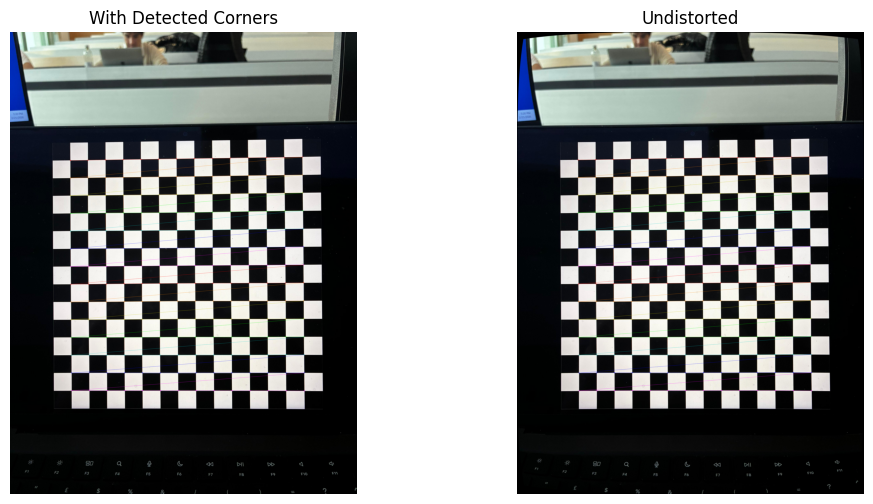

In [4]:
# Show example undistortion on the last image with detected corners
if img_with_corners is not None and 'mtx' in globals():
    img = img_with_corners
    h, w = img.shape[:2]
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
    undist = cv2.undistort(img, mtx, dist, None, newcameramtx)

    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.title('With Detected Corners')
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Undistorted')
    plt.imshow(cv2.cvtColor(undist, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
else:
    print('No example image to show undistortion.')

In [5]:
# Export calibration to JSON and YAML (OpenCV FileStorage)
import numpy as np
import json
import cv2
from pathlib import Path

data_path = Path('calibration.npz')
if not data_path.exists():
    print('calibration.npz not found. Run calibration first.')
else:
    data = np.load(str(data_path))
    mtx = data['camera_matrix']
    dist = data['dist_coeffs']
    reproj = float(data['reprojection_error']) if 'reprojection_error' in data else None

    # Write JSON
    out_json = {
        'camera_matrix': mtx.tolist(),
        'dist_coeffs': dist.ravel().tolist(),
        'reprojection_error': reproj
    }
    with open('calibration.json', 'w') as f:
        json.dump(out_json, f, indent=2)

    # Write YAML using OpenCV FileStorage
    fs = cv2.FileStorage('calibration.yml', cv2.FILE_STORAGE_WRITE)
    fs.write('camera_matrix', mtx)
    fs.write('dist_coeffs', dist)
    if reproj is not None:
        fs.write('reprojection_error', reproj)
    fs.release()

    print('Wrote calibration.json and calibration.yml')

Wrote calibration.json and calibration.yml


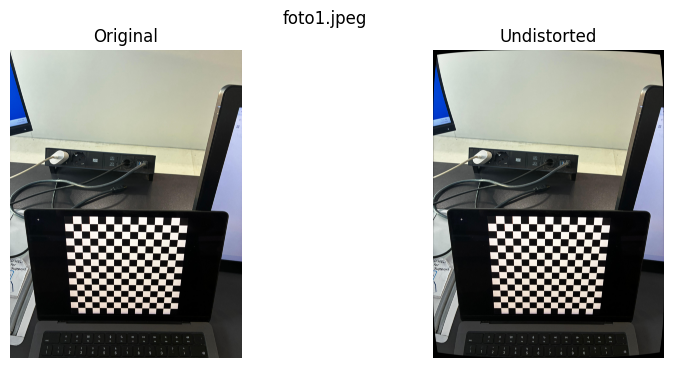

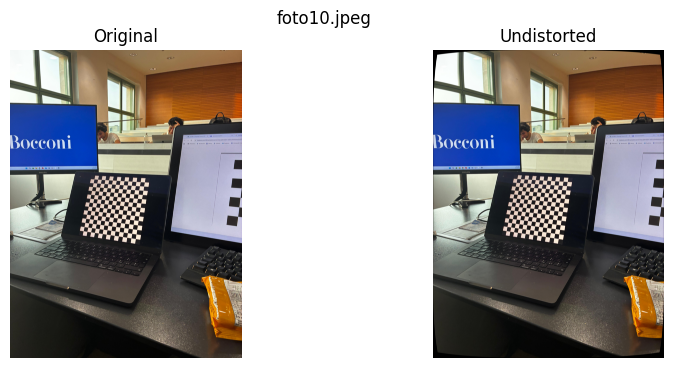

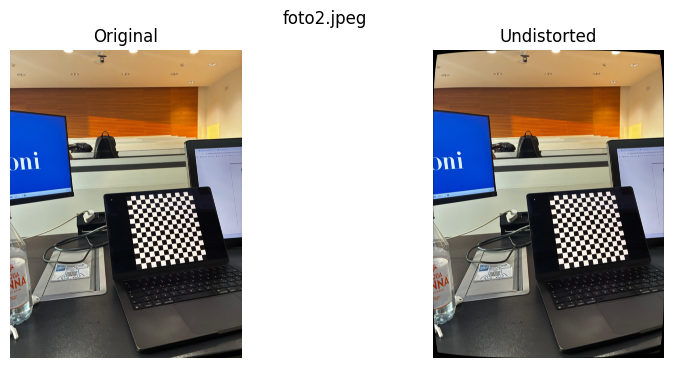

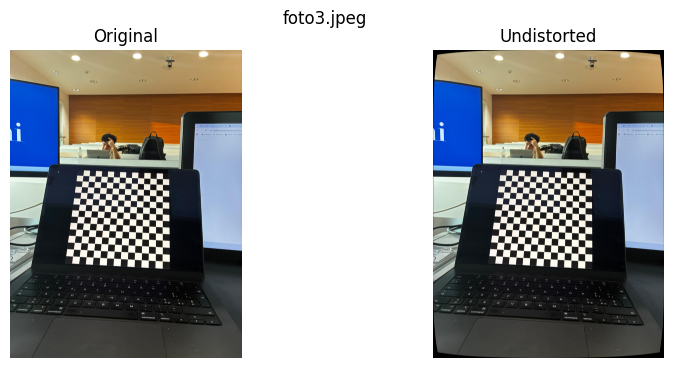

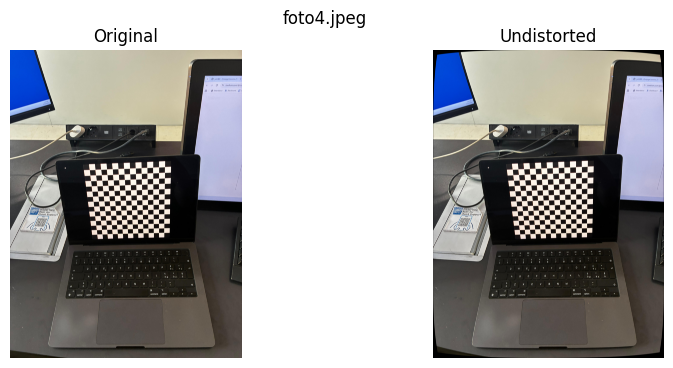

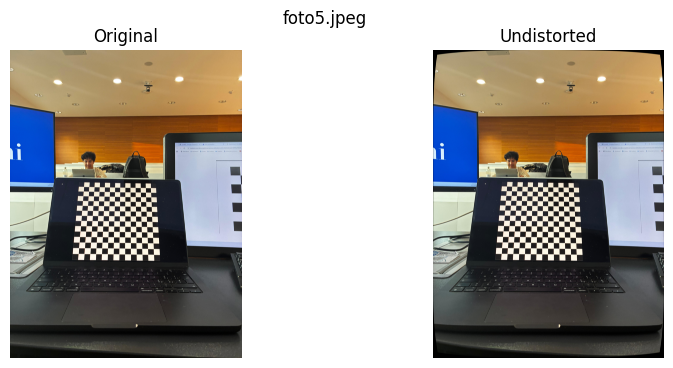

In [1]:
# Additional examples: undistort several images using the saved calibration
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt

# load previously saved calibration parameters
calib = np.load('calibration.npz')
mtx = calib['camera_matrix']
dist = calib['dist_coeffs']

# collect all image files again
images = sorted(glob.glob('*.jpeg') + glob.glob('*.jpg') + glob.glob('*.png'))

if not images:
    print('No images found in working directory to undistort.')
else:
    # display a few examples side by side
    for fname in images[:6]:  # change number as needed
        img = cv2.imread(fname)
        h, w = img.shape[:2]
        newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
        undist = cv2.undistort(img, mtx, dist, None, newcameramtx)

        plt.figure(figsize=(10, 4))
        plt.suptitle(fname)
        plt.subplot(1, 2, 1)
        plt.title('Original')
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title('Undistorted')
        plt.imshow(cv2.cvtColor(undist, cv2.COLOR_BGR2RGB))
        plt.axis('off')

        plt.show()

Undistorted images saved to /Users/alessandrobottardi/Desktop/bocconi/AI/compvision/hw/undistorted


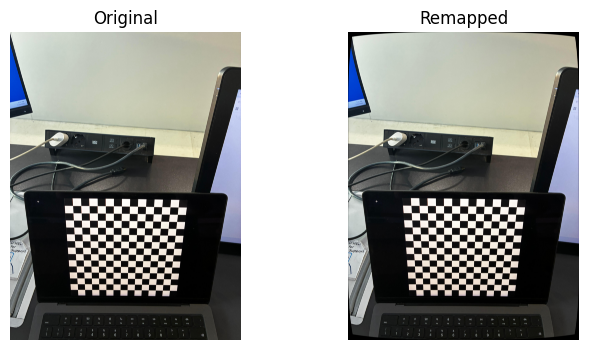

In [2]:
# save undistorted outputs for all images to an "undistorted" folder
import os
os.makedirs('undistorted', exist_ok=True)

for fname in images:
    img = cv2.imread(fname)
    h, w = img.shape[:2]
    newcameramtx, roi = cv2.getOptimalNewCameraMatrix(mtx, dist, (w, h), 1, (w, h))
    undist = cv2.undistort(img, mtx, dist, None, newcameramtx)
    # crop to ROI if desired
    x, y, w2, h2 = roi
    if w2 > 0 and h2 > 0:
        undist = undist[y:y+h2, x:x+w2]
    outname = os.path.join('undistorted', os.path.basename(fname))
    cv2.imwrite(outname, undist)

print(f'Undistorted images saved to {os.path.abspath("undistorted")}')

# also demonstrate remapping approach (useful for video)
mapx, mapy = cv2.initUndistortRectifyMap(mtx, dist, None, newcameramtx, (w, h), cv2.CV_32FC1)
example = cv2.imread(images[0])
remapped = cv2.remap(example, mapx, mapy, cv2.INTER_LINEAR)
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.title('Original'); plt.imshow(cv2.cvtColor(example, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.subplot(1,2,2); plt.title('Remapped'); plt.imshow(cv2.cvtColor(remapped, cv2.COLOR_BGR2RGB)); plt.axis('off')
plt.show()